In [1]:
from ib_async import *

util.startLoop()

ib = IB()
ib.connect("127.0.0.1", 7497, clientId=14)
ib.

<IB connected to 127.0.0.1:7497 clientId=14>

Error 10314, reqId 7: End Date/Time: The date, time, or time-zone entered is invalid. The correct format is yyyymmdd hh:mm:ss xx/xxxx where yyyymmdd and xx/xxxx are optional. E.g.: 20031126 15:59:00 US/Eastern  Note that there is a space between the date and time, and between the time and time-zone.  If no date is specified, current date is assumed. If no time-zone is specified, local time-zone is assumed(deprecated).  You can also provide yyyymmddd-hh:mm:ss time is in UTC. Note that there is a dash between the date and time in UTC notation., contract: Stock(conId=76792991, symbol='TSLA', exchange='SMART', primaryExchange='NASDAQ', currency='USD', localSymbol='TSLA', tradingClass='NMS')
Error 10314, reqId 8: End Date/Time: The date, time, or time-zone entered is invalid. The correct format is yyyymmdd hh:mm:ss xx/xxxx where yyyymmdd and xx/xxxx are optional. E.g.: 20031126 15:59:00 US/Eastern  Note that there is a space between the date and time, and between the time and time-zone.  If

In [ ]:
# contract = Stock("GOOG", "SMART", "USD")
contract=Crypto("BTC", "PAXOS", "USD")
# contract=Forex('EURUSD')
# contract=Future("ES", "20260320", "CME")
# contract=Option(symbol="BANKNIFTY", lastTradeDateOrContractMonth="20260330", strike=60500, right="C", exchange="NSE")
b=ib.qualifyContracts(contract)
contract=b[0]
contract
# ib.reqHeadTimeStamp(contract, whatToShow="TRADES", useRTH=True)

Stock(conId=208813720, symbol='GOOG', exchange='SMART', primaryExchange='NASDAQ', currency='USD', localSymbol='GOOG', tradingClass='NMS')

In [52]:
bars = ib.reqHistoricalData(
    contract,
    endDateTime="",
    durationStr="5 D",
    barSizeSetting="1 min",
    whatToShow="MIDPOINT",
    useRTH=True,
    formatDate=1,
)
bars

[BarData(date=datetime.datetime(2026, 3, 2, 9, 30, tzinfo=zoneinfo.ZoneInfo(key='US/Eastern')), open=302.93, high=303.66, low=301.09, close=302.45, volume=-1.0, average=-1.0, barCount=-1),
 BarData(date=datetime.datetime(2026, 3, 2, 9, 31, tzinfo=zoneinfo.ZoneInfo(key='US/Eastern')), open=302.45, high=303.28, low=302.27, close=303.2, volume=-1.0, average=-1.0, barCount=-1),
 BarData(date=datetime.datetime(2026, 3, 2, 9, 32, tzinfo=zoneinfo.ZoneInfo(key='US/Eastern')), open=303.2, high=303.96, low=302.58, close=303.86, volume=-1.0, average=-1.0, barCount=-1),
 BarData(date=datetime.datetime(2026, 3, 2, 9, 33, tzinfo=zoneinfo.ZoneInfo(key='US/Eastern')), open=303.86, high=303.93, low=303.07, close=303.5, volume=-1.0, average=-1.0, barCount=-1),
 BarData(date=datetime.datetime(2026, 3, 2, 9, 34, tzinfo=zoneinfo.ZoneInfo(key='US/Eastern')), open=303.5, high=305.11, low=303.31, close=304.84, volume=-1.0, average=-1.0, barCount=-1),
 BarData(date=datetime.datetime(2026, 3, 2, 9, 35, tzinfo=z

In [53]:
df = util.df(bars)
df

,date,open,high,low,close,volume,average,barCount
0,2026-03-02 09:30:00-05:00,302.93,303.66,301.09,302.45,-1.0,-1.0,-1
1,2026-03-02 09:31:00-05:00,302.45,303.28,302.27,303.20,-1.0,-1.0,-1
2,2026-03-02 09:32:00-05:00,303.20,303.96,302.58,303.86,-1.0,-1.0,-1
3,2026-03-02 09:33:00-05:00,303.86,303.93,303.07,303.50,-1.0,-1.0,-1
4,2026-03-02 09:34:00-05:00,303.50,305.11,303.31,304.84,-1.0,-1.0,-1
...,...,...,...,...,...,...,...,...
1945,2026-03-06 15:55:00-05:00,298.35,298.45,297.80,297.81,-1.0,-1.0,-1
1946,2026-03-06 15:56:00-05:00,297.81,298.13,297.72,298.09,-1.0,-1.0,-1
1947,2026-03-06 15:57:00-05:00,298.09,298.60,298.07,298.52,-1.0,-1.0,-1
1948,2026-03-06 15:58:00-05:00,298.52,298.53,298.25,298.33,-1.0,-1.0,-1


<Axes: >

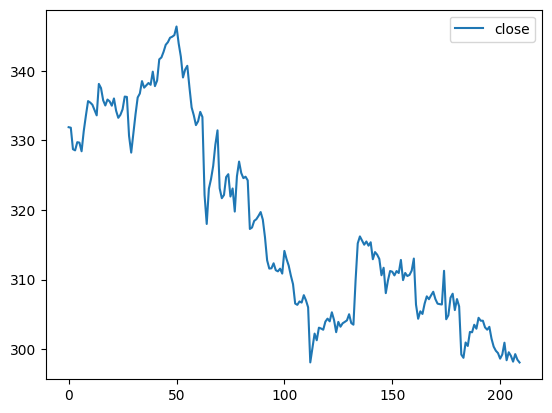

In [48]:
df.plot(y='close')

In [50]:
%matplotlib inline

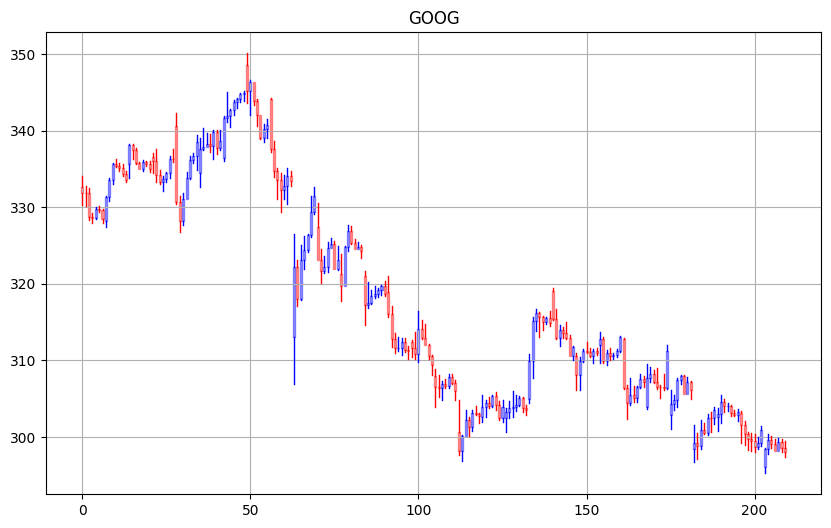

In [51]:
util.barplot(df, title=contract.symbol);